# EMNIST Digits — K-Means on CPU
## Same preprocessing and evaluation pipeline as the original clustering notebook

### Dataset
**EMNIST Digits**
- 240,000 training images available
- \(28\times28=784\) raw pixel features
- 10 digit classes
- one fixed **20,000-image** subset is used
- true digit labels are **not** used during K-Means fitting; they are used only for evaluation

### CPU-only design
This version deliberately uses:
- **CPU:** scikit-learn `KMeans`
- **No RAPIDS / cuML**
- **No CuPy**
- **No CUDA/GPU benchmark**

### Pipeline kept the same
1. Load EMNIST Digits
2. Select the same-size fixed 20,000-image subset
3. Correct EMNIST image orientation
4. Flatten \(28\times28 \rightarrow 784\)
5. Normalize pixels to `[0,1]`
6. Standardize features
7. Reduce to **50 PCA components**
8. Run **K-Means with \(K=10\)**
9. Repeat the clustering **3 times**
10. Measure fit time, throughput, peak process RAM, energy, and CO₂e
11. Compute external and internal clustering-quality metrics
12. Plot results and save CSV/PNG outputs

> On Kaggle, this notebook is intended for a **CPU session**. GPU is not required.


## 1. Install and import packages

In [1]:
import os

# Make the notebook CPU-only even if it is opened in a GPU-enabled runtime.
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import subprocess
import sys
import importlib.util

def ensure_package(module_name, package_name=None):
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name or module_name,
        ])

ensure_package("codecarbon")

import gc
import time
import random
import platform
import threading
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import torch
from torchvision import datasets

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

print("Environment")
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("scikit-learn CPU K-Means only")
print("CPU:", platform.processor() or "OS-reported CPU")
print("Logical CPU cores:", os.cpu_count())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 80.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.0 which is incompatible.


Environment
Python: 3.12.13
PyTorch: 2.10.0+cpu
scikit-learn CPU K-Means only
CPU: x86_64
Logical CPU cores: 4
CUDA_VISIBLE_DEVICES: 


## 2. Controlled experimental configuration

In [2]:
SEED = 42

# Same subset size as the original notebook.
CLUSTERING_SAMPLES = 20_000

# Same shared preprocessing.
PCA_DIMS = 50

# Same K-Means settings.
K = 10
KMEANS_N_INIT = 10
KMEANS_MAX_ITER = 300
KMEANS_TOL = 1e-4

# Same repeated-run design.
N_REPEATS = 3

# Same practical limit for silhouette evaluation.
SILHOUETTE_SAMPLE_SIZE = 10_000

# CodeCarbon sampling interval.
CARBON_MEASURE_SECS = 1

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)

print({
    "clustering samples": CLUSTERING_SAMPLES,
    "PCA dimensions": PCA_DIMS,
    "K": K,
    "n_init": KMEANS_N_INIT,
    "max_iter": KMEANS_MAX_ITER,
    "tol": KMEANS_TOL,
    "repetitions": N_REPEATS,
    "silhouette sample": SILHOUETTE_SAMPLE_SIZE,
})


{'clustering samples': 20000, 'PCA dimensions': 50, 'K': 10, 'n_init': 10, 'max_iter': 300, 'tol': 0.0001, 'repetitions': 3, 'silhouette sample': 10000}


## 3. Load and preview EMNIST Digits

100%|██████████| 562M/562M [00:01<00:00, 293MB/s]


Dataset: EMNIST Digits
Training images: 240000
Raw image size: (28, 28)
Raw flattened features: 784
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


,digit,count
0,0,24000
1,1,24000
2,2,24000
3,3,24000
4,4,24000
5,5,24000
6,6,24000
7,7,24000
8,8,24000
9,9,24000


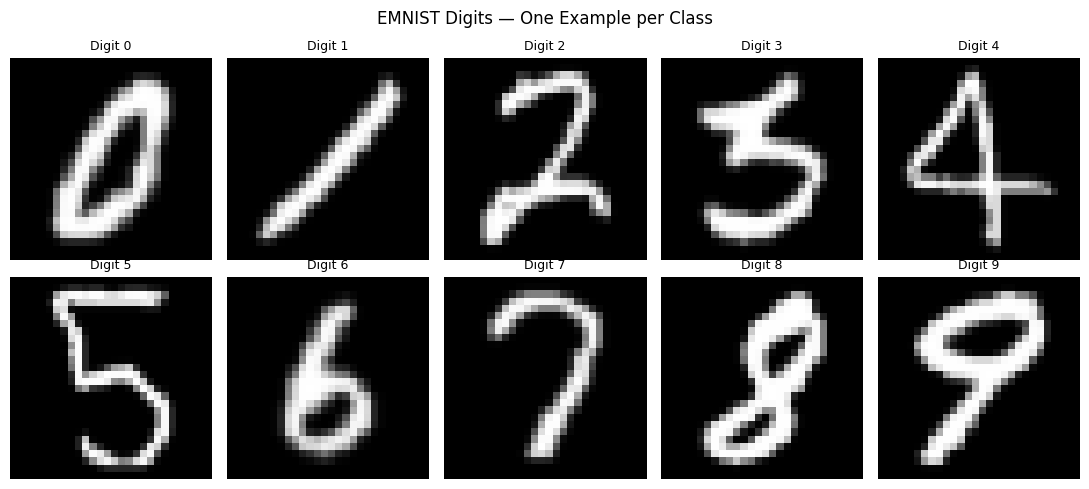

In [3]:
dataset = datasets.EMNIST(
    "./data",
    split="digits",
    train=True,
    download=True,
)

print("Dataset: EMNIST Digits")
print("Training images:", len(dataset))
print("Raw image size:", tuple(dataset.data.shape[1:]))
print("Raw flattened features:", int(np.prod(dataset.data.shape[1:])))
print("Classes:", sorted(dataset.targets.unique().tolist()))

counts = np.bincount(
    dataset.targets.numpy(),
    minlength=10,
)

display(
    pd.DataFrame({
        "digit": np.arange(10),
        "count": counts,
    })
)

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
targets_np = dataset.targets.numpy()

for digit, ax in enumerate(axes.ravel()):
    idx = int(np.flatnonzero(targets_np == digit)[0])

    # EMNIST is stored transposed relative to conventional display.
    ax.imshow(
        dataset.data[idx].numpy().T,
        cmap="gray",
    )
    ax.set_title(f"Digit {digit}", fontsize=9)
    ax.axis("off")

fig.suptitle("EMNIST Digits — One Example per Class")
fig.tight_layout()
fig.savefig("emnist_kmeans_cpu_dataset_preview.png", dpi=160)
plt.show()


## 4. Build the feature matrix

Preprocessing is performed **once on CPU** and excluded from K-Means fit time:

1. select one fixed shuffled **20,000-image** subset;
2. orient each image correctly;
3. flatten \(28\times28\rightarrow784\);
4. normalize pixels to `[0,1]`;
5. standardize features;
6. reduce to 50 PCA components.

The resulting matrix is the input to every repeated K-Means run.


In [4]:
def build_features():
    rng = np.random.RandomState(SEED)
    n_total = len(dataset)

    if CLUSTERING_SAMPLES > n_total:
        raise ValueError(
            f"CLUSTERING_SAMPLES={CLUSTERING_SAMPLES:,} "
            f"exceeds dataset size {n_total:,}."
        )

    # One fixed set of observations for every repetition.
    shared_indices = rng.permutation(n_total)[:CLUSTERING_SAMPLES]

    raw = dataset.data[shared_indices]
    labels = (
        dataset.targets[shared_indices]
        .numpy()
        .astype(np.int32)
    )

    # Correct EMNIST orientation, flatten, normalize.
    X = (
        raw.float()
        .transpose(1, 2)
        .contiguous()
        .view(len(shared_indices), -1)
        .numpy()
        / 255.0
    ).astype(np.float32)

    preprocessing_start = time.perf_counter()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    pca = PCA(
        n_components=PCA_DIMS,
        svd_solver="randomized",
        random_state=SEED,
    )

    X_pca = pca.fit_transform(X_scaled).astype(np.float32)
    preprocessing_time_s = time.perf_counter() - preprocessing_start

    return (
        X_pca,
        labels,
        shared_indices,
        preprocessing_time_s,
        pca.explained_variance_ratio_.sum(),
    )

X_shared, y_shared, shared_indices, preprocessing_time_s, pca_variance = (
    build_features()
)

print("K-Means matrix:", X_shared.shape)
print("Labels:", y_shared.shape)
print(f"Preprocessing time (excluded from fit benchmark): {preprocessing_time_s:.3f} s")
print(f"PCA explained variance retained: {pca_variance:.4f}")

assert X_shared.shape == (CLUSTERING_SAMPLES, PCA_DIMS)
assert len(y_shared) == CLUSTERING_SAMPLES


K-Means matrix: (20000, 50)
Labels: (20000,)
Preprocessing time (excluded from fit benchmark): 2.535 s
PCA explained variance retained: 0.7277


## 5. CodeCarbon and peak-memory helpers

In [5]:
process = psutil.Process(os.getpid())


class PeakMemory:
    def __init__(self, interval=0.10):
        self.interval = interval
        self.peak_rss = 0
        self.stop_event = threading.Event()
        self.thread = None

    def _watch(self):
        while not self.stop_event.is_set():
            try:
                self.peak_rss = max(
                    self.peak_rss,
                    process.memory_info().rss,
                )
            except Exception:
                pass

            time.sleep(self.interval)

    def start(self):
        self.peak_rss = process.memory_info().rss
        self.stop_event.clear()

        self.thread = threading.Thread(
            target=self._watch,
            daemon=True,
        )
        self.thread.start()

    def stop(self):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join(timeout=2)

        return self.peak_rss / (1024 ** 2)


class EnergyTracker:
    def __init__(self, project_name):
        self.tracker = None

        try:
            kwargs = dict(
                project_name=project_name,
                measure_power_secs=CARBON_MEASURE_SECS,
                tracking_mode="process",

                # Explicitly exclude GPUs: this notebook measures CPU execution.
                gpu_ids=[],

                log_level="error",
            )

            try:
                self.tracker = EmissionsTracker(
                    output_methods=[],
                    **kwargs,
                )
            except TypeError:
                # Compatibility fallback for CodeCarbon versions
                # that use the older save_to_* arguments.
                self.tracker = EmissionsTracker(
                    save_to_file=False,
                    save_to_api=False,
                    **kwargs,
                )

        except Exception as exc:
            print("CodeCarbon initialization unavailable:", exc)

    def start(self):
        if self.tracker is not None:
            try:
                self.tracker.start()
            except Exception as exc:
                print("CodeCarbon start failed:", exc)
                self.tracker = None

    def stop(self):
        if self.tracker is None:
            return self.empty()

        try:
            self.tracker.stop()

            data = getattr(
                self.tracker,
                "final_emissions_data",
                None,
            )

            if data is None:
                return self.empty()

            def attr(name):
                value = getattr(data, name, np.nan)
                return np.nan if value is None else value

            return {
                "energy_kwh": attr("energy_consumed"),
                "co2_kg": attr("emissions"),
                "cpu_energy_kwh": attr("cpu_energy"),
                "ram_energy_kwh": attr("ram_energy"),
                "cpu_power_w": attr("cpu_power"),
                "cpu_utilization_pct": attr("cpu_utilization_percent"),
                "country": getattr(data, "country_name", None),
            }

        except Exception as exc:
            print("CodeCarbon stop failed:", exc)
            return self.empty()

    @staticmethod
    def empty():
        return {
            "energy_kwh": np.nan,
            "co2_kg": np.nan,
            "cpu_energy_kwh": np.nan,
            "ram_energy_kwh": np.nan,
            "cpu_power_w": np.nan,
            "cpu_utilization_pct": np.nan,
            "country": None,
        }


## 6. K-Means estimator

In [6]:
def make_kmeans(run_seed):
    return KMeans(
        n_clusters=K,
        init="k-means++",
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER,
        tol=KMEANS_TOL,
        random_state=run_seed,
        algorithm="lloyd",
    )

print("K-Means CPU settings:")
print({
    "n_clusters": K,
    "init": "k-means++",
    "n_init": KMEANS_N_INIT,
    "max_iter": KMEANS_MAX_ITER,
    "tol": KMEANS_TOL,
    "algorithm": "lloyd",
})


K-Means CPU settings:
{'n_clusters': 10, 'init': 'k-means++', 'n_init': 10, 'max_iter': 300, 'tol': 0.0001, 'algorithm': 'lloyd'}


## 7. Clustering quality metrics

The true digit labels are used **only after fitting**.

### External metrics
- NMI
- AMI
- ARI
- Homogeneity
- Completeness
- V-measure

### Internal metrics
- Silhouette score
- Davies–Bouldin index
- Calinski–Harabasz score

Silhouette is calculated on at most 10,000 points to avoid an unnecessary
\(O(n^2)\) full 20,000-point calculation.


In [7]:
def safe_silhouette_subset(labels, max_samples, seed):
    labels = np.asarray(labels)
    n = len(labels)
    unique_labels = np.unique(labels)

    if n < 3 or len(unique_labels) < 2:
        return None

    target_n = min(max_samples, n)
    rng = np.random.RandomState(seed)

    # Guarantee that more than one cluster is represented.
    chosen = []

    shuffled_clusters = unique_labels.copy()
    rng.shuffle(shuffled_clusters)

    for cluster_id in shuffled_clusters[:target_n]:
        cluster_indices = np.flatnonzero(labels == cluster_id)

        if len(cluster_indices) > 0:
            chosen.append(int(rng.choice(cluster_indices)))

    chosen = np.asarray(chosen, dtype=np.int64)

    remaining_slots = target_n - len(chosen)

    if remaining_slots > 0:
        available = np.setdiff1d(
            np.arange(n),
            chosen,
            assume_unique=False,
        )

        extra_n = min(remaining_slots, len(available))

        if extra_n > 0:
            extra = rng.choice(
                available,
                size=extra_n,
                replace=False,
            )
            chosen = np.concatenate([chosen, extra])

    rng.shuffle(chosen)

    sampled_labels = labels[chosen]

    if (
        len(np.unique(sampled_labels)) < 2
        or len(np.unique(sampled_labels)) >= len(sampled_labels)
    ):
        return None

    return chosen


def clustering_metrics(X, predicted, true_labels, metric_seed):
    labels = np.asarray(predicted).reshape(-1)
    y_true = np.asarray(true_labels).reshape(-1)

    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    # External metrics: labels are used only here, after unsupervised fitting.
    nmi = normalized_mutual_info_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels)
    ari = adjusted_rand_score(y_true, labels)
    homogeneity = homogeneity_score(y_true, labels)
    completeness = completeness_score(y_true, labels)
    v_measure = v_measure_score(y_true, labels)

    silhouette = np.nan
    davies_bouldin = np.nan
    calinski_harabasz = np.nan

    valid_internal = (
        len(X) >= 3
        and n_clusters >= 2
        and n_clusters < len(X)
    )

    if valid_internal:
        sample_idx = safe_silhouette_subset(
            labels=labels,
            max_samples=SILHOUETTE_SAMPLE_SIZE,
            seed=metric_seed,
        )

        if sample_idx is not None:
            try:
                silhouette = silhouette_score(
                    X[sample_idx],
                    labels[sample_idx],
                    metric="euclidean",
                )
            except ValueError as exc:
                print("Silhouette skipped:", exc)

        try:
            davies_bouldin = davies_bouldin_score(X, labels)
        except ValueError as exc:
            print("Davies-Bouldin skipped:", exc)

        try:
            calinski_harabasz = calinski_harabasz_score(X, labels)
        except ValueError as exc:
            print("Calinski-Harabasz skipped:", exc)

    return {
        "n_clusters": n_clusters,
        "noise_fraction": 0.0,  # K-Means assigns every point.
        "nmi_all": nmi,
        "ami_all": ami,
        "ari_all": ari,
        "homogeneity": homogeneity,
        "completeness": completeness,
        "v_measure": v_measure,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
    }


## 8. Run one CPU K-Means configuration

In [8]:
def run_one_kmeans_cpu(X, y, run_seed, repeat):
    estimator = make_kmeans(run_seed)

    tracker = EnergyTracker(
        project_name=f"emnist-kmeans-cpu-r{repeat}"
    )

    memory = PeakMemory()

    # Only K-Means fit_predict is inside the timed region.
    # Evaluation metrics and plotting are excluded.
    tracker.start()
    memory.start()

    start = time.perf_counter()

    predicted = estimator.fit_predict(X)

    fit_time_s = time.perf_counter() - start

    peak_process_ram_mb = memory.stop()
    environmental = tracker.stop()

    labels = np.asarray(
        predicted,
        dtype=np.int32,
    )

    metrics = clustering_metrics(
        X=X,
        predicted=labels,
        true_labels=y,
        metric_seed=run_seed,
    )

    print(
        f"KMeans | CPU | "
        f"repeat={repeat} | "
        f"n={len(X):,} | "
        f"fit={fit_time_s:.3f}s | "
        f"clusters={metrics['n_clusters']} | "
        f"NMI={metrics['nmi_all']:.3f} | "
        f"ARI={metrics['ari_all']:.3f}"
    )

    return {
        "repeat": repeat,
        "seed": run_seed,
        "algorithm": "KMeans",
        "device": "cpu",
        "backend": "sklearn",
        "n_samples": len(X),
        "n_features": X.shape[1],
        "fit_time_s": fit_time_s,
        "throughput_samples_s": len(X) / fit_time_s,
        "peak_process_ram_mb": peak_process_ram_mb,

        **metrics,

        "energy_kwh": environmental["energy_kwh"],
        "co2_kg": environmental["co2_kg"],
        "cpu_energy_kwh": environmental["cpu_energy_kwh"],
        "ram_energy_kwh": environmental["ram_energy_kwh"],
        "cpu_power_w": environmental["cpu_power_w"],
        "cpu_utilization_pct": environmental["cpu_utilization_pct"],
        "carbon_country": environmental["country"],
        "labels": labels,
    }


## 9. Repeated CPU benchmark

In [9]:
results = []

for repeat_idx in range(N_REPEATS):
    repeat = repeat_idx + 1
    run_seed = SEED + repeat_idx

    print("\n" + "=" * 80)
    print(
        f"REPETITION {repeat}/{N_REPEATS} "
        f"| seed={run_seed} "
        f"| K-Means CPU"
    )
    print("=" * 80)

    gc.collect()

    result = run_one_kmeans_cpu(
        X=X_shared,
        y=y_shared,
        run_seed=run_seed,
        repeat=repeat,
    )

    results.append(result)


raw_df = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key != "labels"
    }
    for result in results
])

raw_df["co2_g"] = raw_df["co2_kg"] * 1000
raw_df["energy_wh"] = raw_df["energy_kwh"] * 1000

raw_df["energy_wh_per_1000_samples"] = (
    raw_df["energy_wh"]
    / raw_df["n_samples"]
    * 1000
)

display(raw_df.round(6))



REPETITION 1/3 | seed=42 | K-Means CPU


[codecarbon WARNING @ 08:43:06] Multiple instances of codecarbon are allowed to run at the same time.


KMeans | CPU | repeat=1 | n=20,000 | fit=1.311s | clusters=10 | NMI=0.413 | ARI=0.310

REPETITION 2/3 | seed=43 | K-Means CPU
KMeans | CPU | repeat=2 | n=20,000 | fit=1.153s | clusters=10 | NMI=0.454 | ARI=0.355

REPETITION 3/3 | seed=44 | K-Means CPU
KMeans | CPU | repeat=3 | n=20,000 | fit=0.982s | clusters=10 | NMI=0.452 | ARI=0.352


,repeat,seed,algorithm,device,backend,n_samples,n_features,fit_time_s,throughput_samples_s,peak_process_ram_mb,n_clusters,noise_fraction,nmi_all,ami_all,ari_all,homogeneity,completeness,v_measure,silhouette,davies_bouldin,calinski_harabasz,energy_kwh,co2_kg,cpu_energy_kwh,ram_energy_kwh,cpu_power_w,cpu_utilization_pct,carbon_country,co2_g,energy_wh,energy_wh_per_1000_samples
0,1,42,KMeans,cpu,sklearn,20000,50,1.311100,15254.369459,773.730469,10,0.0,0.412584,0.412056,0.309874,0.404727,0.420753,0.412584,0.056034,2.601356,799.038818,0.000006,0.000001,0.000003,0.000004,4.148366,0,United States,0.000892,0.006431,0.000322
1,2,43,KMeans,cpu,sklearn,20000,50,1.152562,17352.649044,778.085938,10,0.0,0.453664,0.453176,0.354570,0.447187,0.460332,0.453664,0.060753,2.593225,803.917236,0.000006,0.000001,0.000002,0.000003,4.203947,0,United States,0.000777,0.005598,0.000280
2,3,44,KMeans,cpu,sklearn,20000,50,0.982331,20359.735681,778.105469,10,0.0,0.451869,0.451378,0.352237,0.445251,0.458686,0.451869,0.058858,2.593595,803.967346,0.000005,0.000001,0.000002,0.000003,3.417644,0,United States,0.000649,0.004677,0.000234


## 10. Mean ± standard deviation summary

In [10]:
summary_df = pd.DataFrame([{
    "algorithm": "KMeans",
    "device": "cpu",
    "backend": "sklearn",
    "n_samples": int(raw_df["n_samples"].iloc[0]),

    "fit_time_mean_s": raw_df["fit_time_s"].mean(),
    "fit_time_std_s": raw_df["fit_time_s"].std(),

    "throughput_mean_samples_s": raw_df["throughput_samples_s"].mean(),
    "throughput_std_samples_s": raw_df["throughput_samples_s"].std(),

    "n_clusters_mean": raw_df["n_clusters"].mean(),

    "nmi_mean": raw_df["nmi_all"].mean(),
    "nmi_std": raw_df["nmi_all"].std(),

    "ari_mean": raw_df["ari_all"].mean(),
    "ari_std": raw_df["ari_all"].std(),

    "ami_mean": raw_df["ami_all"].mean(),
    "ami_std": raw_df["ami_all"].std(),

    "silhouette_mean": raw_df["silhouette"].mean(),
    "silhouette_std": raw_df["silhouette"].std(),

    "davies_bouldin_mean": raw_df["davies_bouldin"].mean(),
    "davies_bouldin_std": raw_df["davies_bouldin"].std(),

    "calinski_harabasz_mean": raw_df["calinski_harabasz"].mean(),
    "calinski_harabasz_std": raw_df["calinski_harabasz"].std(),

    "energy_mean_kwh": raw_df["energy_kwh"].mean(),
    "energy_std_kwh": raw_df["energy_kwh"].std(),

    "co2_mean_g": raw_df["co2_g"].mean(),
    "co2_std_g": raw_df["co2_g"].std(),

    "peak_ram_mean_mb": raw_df["peak_process_ram_mb"].mean(),
    "peak_ram_std_mb": raw_df["peak_process_ram_mb"].std(),
}])

display(summary_df.round(6))


,algorithm,device,backend,n_samples,fit_time_mean_s,fit_time_std_s,throughput_mean_samples_s,throughput_std_samples_s,n_clusters_mean,nmi_mean,nmi_std,ari_mean,ari_std,ami_mean,ami_std,silhouette_mean,silhouette_std,davies_bouldin_mean,davies_bouldin_std,calinski_harabasz_mean,calinski_harabasz_std,energy_mean_kwh,energy_std_kwh,co2_mean_g,co2_std_g,peak_ram_mean_mb,peak_ram_std_mb
0,KMeans,cpu,sklearn,20000,1.148664,0.164419,17655.584728,2566.129105,10.0,0.439372,0.023216,0.338894,0.025159,0.43887,0.023239,0.058548,0.002375,2.596059,0.004591,802.3078,2.831097,0.000006,0.000001,0.000773,0.000122,776.640625,2.520288


## 11. Fit time and throughput

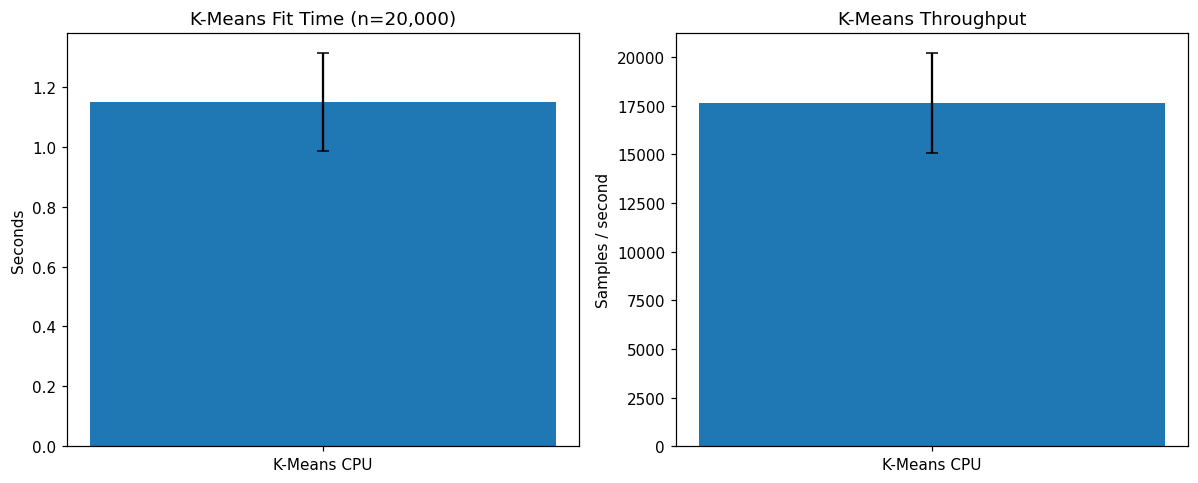

In [11]:
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(
    ["K-Means CPU"],
    [raw_df["fit_time_s"].mean()],
    yerr=[raw_df["fit_time_s"].std()],
    capsize=4,
)
axes[0].set_title(
    f"K-Means Fit Time (n={CLUSTERING_SAMPLES:,})"
)
axes[0].set_ylabel("Seconds")

axes[1].bar(
    ["K-Means CPU"],
    [raw_df["throughput_samples_s"].mean()],
    yerr=[raw_df["throughput_samples_s"].std()],
    capsize=4,
)
axes[1].set_title("K-Means Throughput")
axes[1].set_ylabel("Samples / second")

plt.tight_layout()
plt.savefig("emnist_kmeans_cpu_timing.png", dpi=160)
plt.show()


## 12. External clustering-quality plots

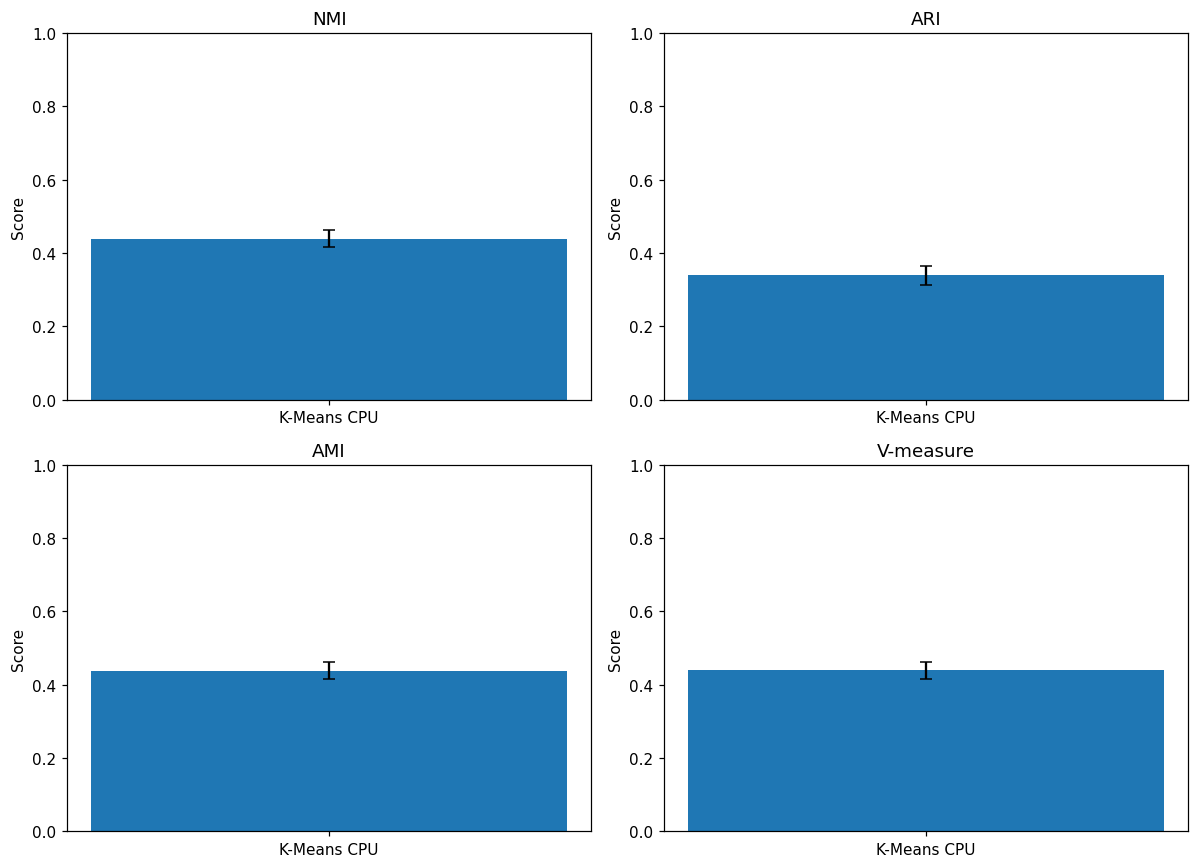

In [12]:
quality_metrics = [
    ("nmi_all", "NMI"),
    ("ari_all", "ARI"),
    ("ami_all", "AMI"),
    ("v_measure", "V-measure"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, (metric, title) in zip(
    axes.ravel(),
    quality_metrics,
):
    mean_value = raw_df[metric].mean()
    std_value = raw_df[metric].std()

    ax.bar(
        ["K-Means CPU"],
        [mean_value],
        yerr=[std_value],
        capsize=4,
    )

    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(
    "emnist_kmeans_cpu_external_metrics.png",
    dpi=160,
)
plt.show()


## 13. Internal clustering-quality plots

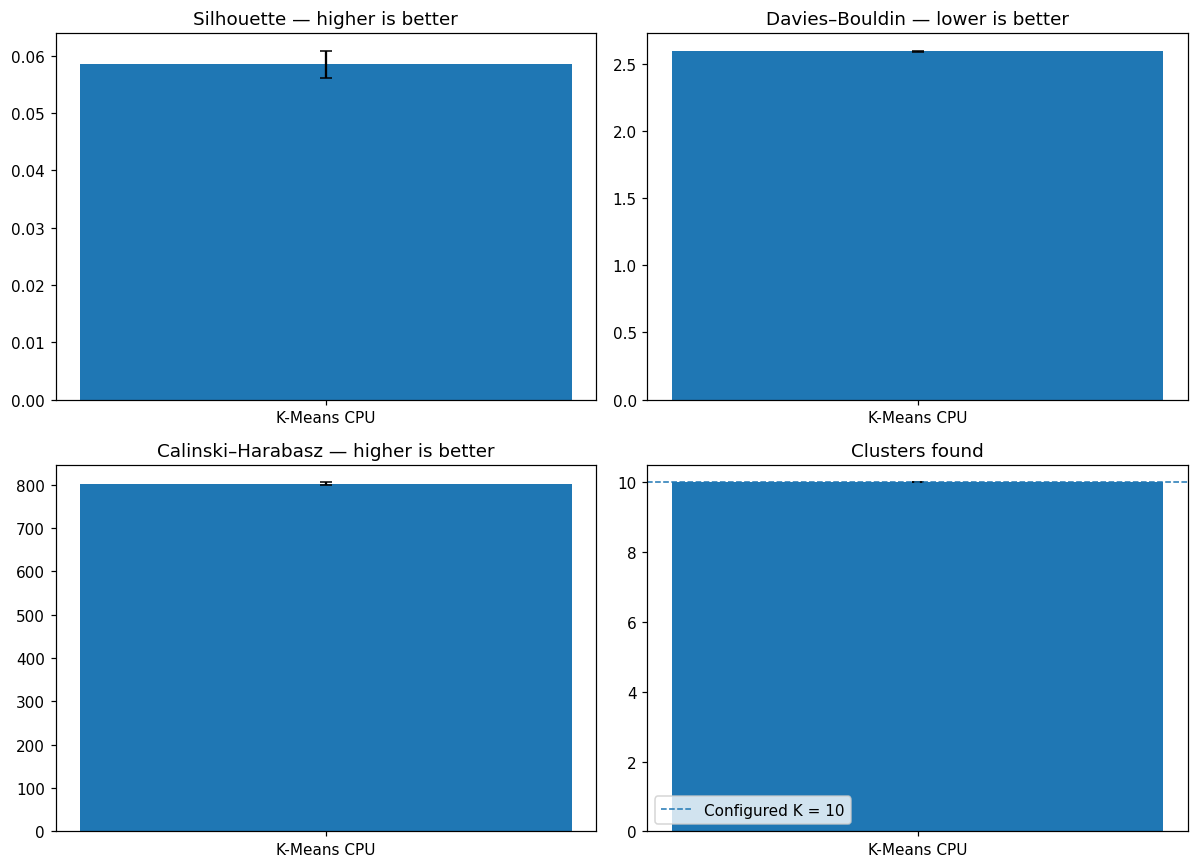

In [13]:
internal_metrics = [
    ("silhouette", "Silhouette — higher is better"),
    ("davies_bouldin", "Davies–Bouldin — lower is better"),
    ("calinski_harabasz", "Calinski–Harabasz — higher is better"),
    ("n_clusters", "Clusters found"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, (metric, title) in zip(
    axes.ravel(),
    internal_metrics,
):
    mean_value = raw_df[metric].mean()
    std_value = raw_df[metric].std()

    ax.bar(
        ["K-Means CPU"],
        [mean_value],
        yerr=[std_value],
        capsize=4,
    )

    ax.set_title(title)

# K should remain 10 for every run.
axes[1, 1].axhline(
    K,
    linestyle="--",
    linewidth=1,
    label="Configured K = 10",
)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(
    "emnist_kmeans_cpu_internal_metrics.png",
    dpi=160,
)
plt.show()


## 14. Energy, carbon, and memory plots

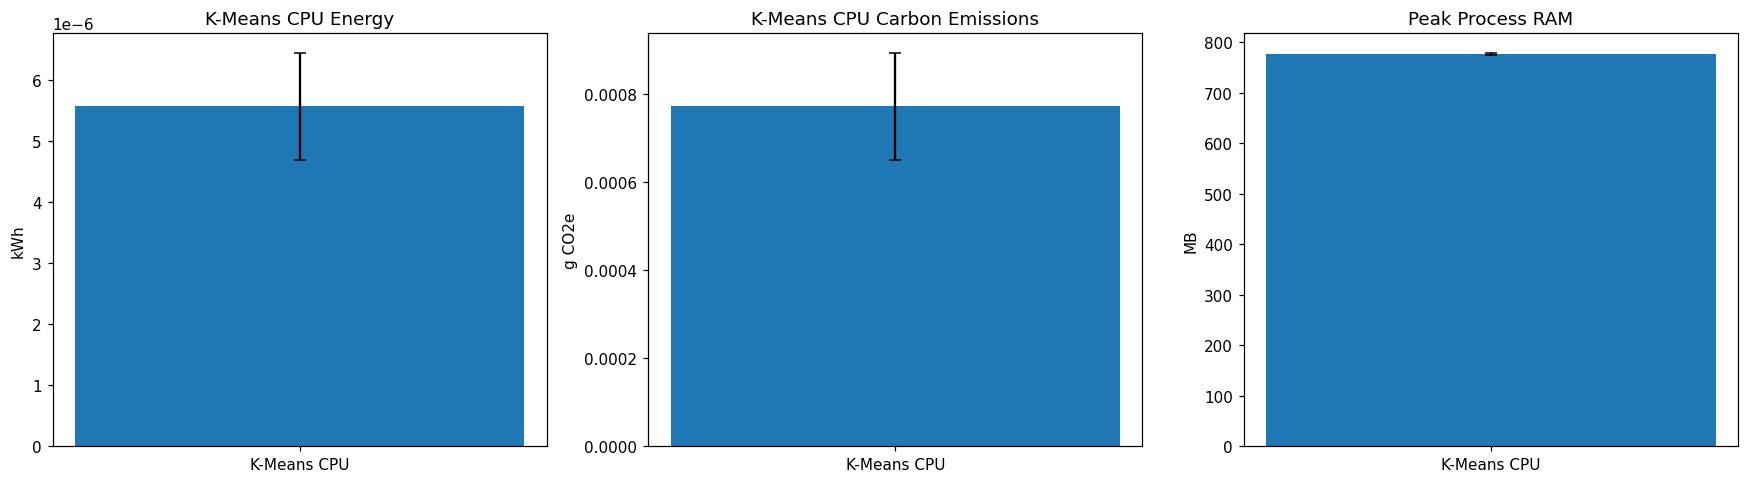

In [14]:
plot_specs = [
    ("energy_kwh", "K-Means CPU Energy", "kWh"),
    ("co2_g", "K-Means CPU Carbon Emissions", "g CO2e"),
    ("peak_process_ram_mb", "Peak Process RAM", "MB"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (metric, title, ylabel) in zip(
    axes,
    plot_specs,
):
    ax.bar(
        ["K-Means CPU"],
        [raw_df[metric].mean()],
        yerr=[raw_df[metric].std()],
        capsize=4,
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig(
    "emnist_kmeans_cpu_energy_carbon_memory.png",
    dpi=160,
)
plt.show()


## 15. 2D PCA visualization of true vs predicted clusters

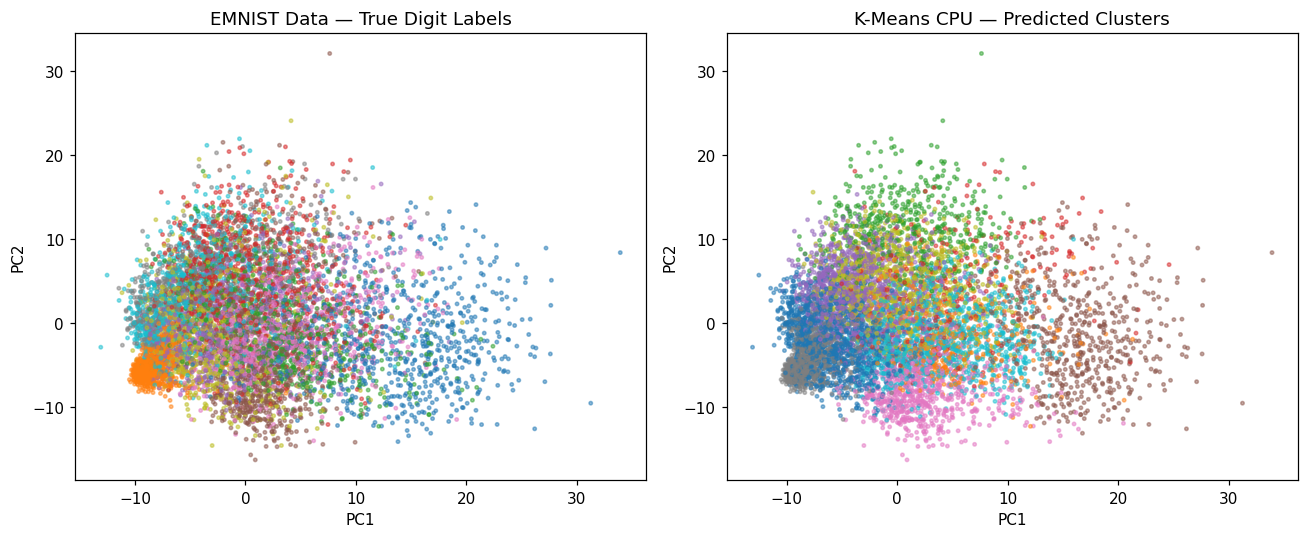

In [15]:
# Use repetition 1 labels for visualization only.
rng = np.random.RandomState(SEED)

z2 = PCA(
    n_components=2,
    random_state=SEED,
).fit_transform(X_shared)

first_result = next(
    result
    for result in results
    if result["repeat"] == 1
)

predicted = first_result["labels"]

sample_idx = rng.permutation(
    len(X_shared)
)[:min(8_000, len(X_shared))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    z2[sample_idx, 0],
    z2[sample_idx, 1],
    c=y_shared[sample_idx],
    s=5,
    cmap="tab10",
    alpha=0.5,
)
axes[0].set_title("EMNIST Data — True Digit Labels")

axes[1].scatter(
    z2[sample_idx, 0],
    z2[sample_idx, 1],
    c=predicted[sample_idx],
    s=5,
    cmap="tab10",
    alpha=0.5,
)
axes[1].set_title("K-Means CPU — Predicted Clusters")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.savefig(
    "emnist_kmeans_cpu_assignments.png",
    dpi=160,
)
plt.show()


## 16. Compact report table

In [16]:
report_table = pd.DataFrame([{
    "algorithm": "KMeans",
    "device": "cpu",
    "backend": "sklearn",
    "samples": int(raw_df["n_samples"].iloc[0]),
    "features_after_pca": int(raw_df["n_features"].iloc[0]),

    "fit_time_s": raw_df["fit_time_s"].mean(),
    "throughput_samples_s": raw_df["throughput_samples_s"].mean(),

    "n_clusters": raw_df["n_clusters"].mean(),

    "nmi": raw_df["nmi_all"].mean(),
    "ari": raw_df["ari_all"].mean(),
    "ami": raw_df["ami_all"].mean(),
    "homogeneity": raw_df["homogeneity"].mean(),
    "completeness": raw_df["completeness"].mean(),
    "v_measure": raw_df["v_measure"].mean(),

    "silhouette": raw_df["silhouette"].mean(),
    "davies_bouldin": raw_df["davies_bouldin"].mean(),
    "calinski_harabasz": raw_df["calinski_harabasz"].mean(),

    "energy_kwh": raw_df["energy_kwh"].mean(),
    "co2_g": raw_df["co2_g"].mean(),
    "peak_process_ram_mb": raw_df["peak_process_ram_mb"].mean(),
}])

display(report_table.round(6))


,algorithm,device,backend,samples,features_after_pca,fit_time_s,throughput_samples_s,n_clusters,nmi,ari,ami,homogeneity,completeness,v_measure,silhouette,davies_bouldin,calinski_harabasz,energy_kwh,co2_g,peak_process_ram_mb
0,KMeans,cpu,sklearn,20000,50,1.148664,17655.584728,10.0,0.439372,0.338894,0.43887,0.432388,0.44659,0.439372,0.058548,2.596059,802.3078,0.000006,0.000773,776.640625


## 17. Save outputs

In [17]:
output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path(".")
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

raw_df.to_csv(
    output_dir / "kmeans_emnist_cpu_raw_results.csv",
    index=False,
)

summary_df.to_csv(
    output_dir / "kmeans_emnist_cpu_summary.csv",
    index=False,
)

report_table.to_csv(
    output_dir / "kmeans_emnist_cpu_report_table.csv",
    index=False,
)

print("Saved CSV outputs to:", output_dir)
print("PNG plots are also created by the plotting cells.")


Saved CSV outputs to: /kaggle/working
PNG plots are also created by the plotting cells.


# Interpretation and methodological limitations

## What this notebook measures

The benchmark is now:

\[
\boxed{\text{K-Means on CPU}}
\]

It is **not** a CPU-vs-GPU comparison and it is **not** a K-Means-vs-DBSCAN comparison.

The principal outputs are:
- clustering fit time;
- throughput;
- peak process RAM;
- estimated energy consumption;
- estimated CO₂e;
- NMI, AMI, ARI, homogeneity, completeness, and V-measure;
- silhouette, Davies–Bouldin, and Calinski–Harabasz scores.

## Experimental controls retained from the original pipeline

- fixed 20,000-image EMNIST subset;
- fixed normalization and StandardScaler preprocessing;
- fixed 50-dimensional PCA representation;
- \(K=10\);
- `n_init=10`;
- `max_iter=300`;
- `tol=1e-4`;
- 3 repeated runs;
- true class labels used only for post-clustering evaluation;
- preprocessing excluded from K-Means fit time;
- metric calculation and plotting excluded from fit time.

## Limitations

1. CodeCarbon estimates energy and CO₂e rather than directly measuring wall-socket electricity.
2. Very short CPU runs can make energy estimates noisier than runtime measurements.
3. PCA and scaling are performed once before the repeated benchmark and are therefore not included in clustering fit time.
4. Silhouette is evaluated on at most 10,000 samples for computational feasibility.
5. EMNIST digit labels are used only after clustering to evaluate cluster agreement; they are never supplied to K-Means during fitting.
